In [1]:
import matplotlib.pylab as plt
import numpy as np
import pandas as pd #######

In [2]:
##### with front changing occupancy

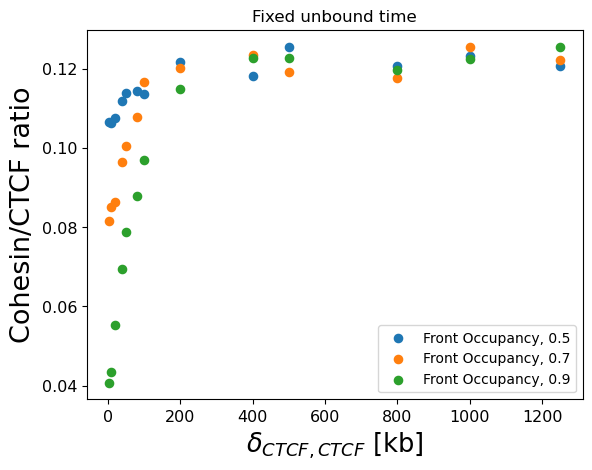

In [3]:
file = pd.read_csv('merged_frip_frontbarrier.csv')
file['birthp']=(file['birth']/0.0001).astype(int)
file = file[file['birthp']==1]
#file = file[file['deltactcf'].isin(delta_list)]
file['deltactcf']=file['deltactcf']*0.125   # to convert to base pairs, considering that deltactcf/2 is the distance  
file = file[file['cof']==17.0]
file ['occup']=(file['clife']/(file['clife']+file['cof'])).round(2)
file = file.query('occup>0.4')
unique_dch = np.unique(file['deltacoh'])
unique_occup = [0.5, 0.7, 0.9]
#unique_occup = np.unique(file['occup'])
file = file[file['deltactcf']>2]
for dch_val in unique_dch:
    for occup_val in unique_occup:
        new_file = file[(file['occup']==occup_val)&(file['deltacoh']==dch_val)]
        #print(new_file)
        plt.scatter(new_file['deltactcf'],new_file['reads_c']/new_file['ctcf_reads_c'],s=35, label='Front Occupancy, %s'%occup_val)
        # Customize 
        plt.title('Fixed unbound time')
        plt.xlabel(r'$\delta_{CTCF, CTCF}$ [kb]', fontsize = 18.5)
        plt.xticks(fontsize =11.5)
        #plt.xscale('log')
        plt.legend()
        plt.ylabel('Cohesin/CTCF ratio', fontsize =19.5)
        plt.yticks(fontsize=11.5, rotation=0)
        
    #plt.savefig('frip_vs_distance_sequential.pdf', bbox_inches = 'tight')
    plt.show()

In [4]:
##### with both changing occupancy

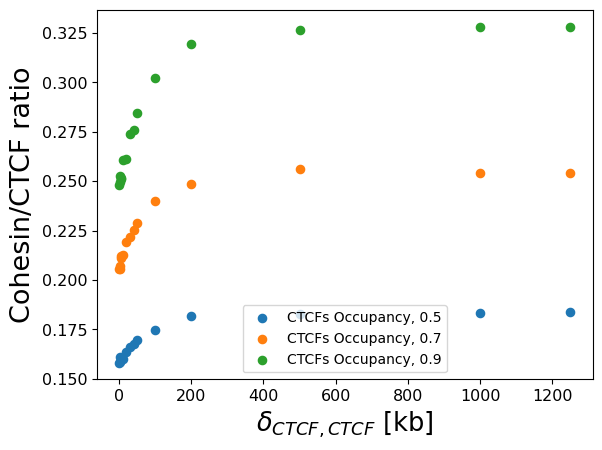

In [5]:
file = pd.read_csv('merged_frip_bothbarriers.csv') # this file includes simulations where both ctcf change occupancy
file=file[(file['life']==66)&(file['sep']==74)]
file['birthp']=(file['birth']/0.0001).astype(int)
file = file[file['birthp']==1]
file = file[file['deltactcf']<19000]
file['deltactcf']=file['deltactcf']*0.125
birth = file['birth']
deltactcf = file['deltactcf']
unique_birth=np.unique(birth)
unique_deltactcf = np.unique(deltactcf)
unique_cof = np.unique(file['cof'])
file = file[file['clife']==17.0]
file ['occup']=(file['clife']/(file['clife']+file['cof'])).round(3)
file = file.query('occup>0.4')
unique_occup = np.unique(file['occup'])
unique_dch = np.unique(file['deltacoh'])
unique_occup = [0.5, 0.7, 0.9]
for dch_val in unique_dch:
    for occup_val in unique_occup:
        #print(occup_val)
        new_file = file[(file['occup']==occup_val)&(file['deltacoh']==dch_val)]
        #print(new_file)
        plt.scatter(new_file['deltactcf'],new_file['reads_c']/new_file['ctcf_reads_c'],s=35, label='CTCFs Occupancy, %s'%occup_val)
        # Customize 
        plt.xlabel(r'$\delta_{CTCF, CTCF}$ [kb]', fontsize = 18.5)
        plt.xticks(fontsize =11.5)
        plt.ylabel('Cohesin/CTCF ratio', fontsize =19.5)
        plt.yticks(fontsize=11.5, rotation=0)
        #plt.xscale('log')
        plt.legend()
    plt.show()